# Fase 4 · Chat sobre el histórico (Bloque 2)

**Objetivo:** responder preguntas sobre las 55 ruedas de prensa de la era Lagarde con citas verificables a los fragmentos de los que sale cada afirmación (RAG: recuperación de fragmentos y generación con un LLM). La fase elige el modelo de recuperación, construye el índice que usa la app y comprueba el chat de principio a fin.

In [1]:
# autoreload solo vigila nuestro código (src), no las librerías instaladas
%load_ext autoreload
%autoreload 1
%aimport src.config, src.text.rag, src.text.rag_eval

import time

import matplotlib.pyplot as plt
import pandas as pd

from src.config import ROOT, HISTORY_DIR
from src.text.rag import construir_fragmentos, guardar_indice, preparar, responder
from src.text.rag_eval import (consultas_evaluacion, evaluar_candidatos, tabla_resultados,
                               comparar_con_mejor, elegir_ganador)

resultados_dir = ROOT / "benchmarks" / "results" / "chat"
resultados_dir.mkdir(parents=True, exist_ok=True)

## 1. Diseño del chat

- **Fragmentos.** Párrafos de la declaración y de las respuestas del panel (presidenta, vicepresidente y gobernadores anfitriones). Los de más de 150 palabras se dividen en bloques de frases consecutivas de tamaño parecido: así caben en el contexto de todos los candidatos (el menor, el de MiniLM, admite unas 190 palabras; solo algún bloque aislado lo supera) y cada cita apunta a un pasaje concreto. Se descartan los fragmentos de menos de 8 palabras (fórmulas de cortesía) y las preguntas de los periodistas, que no son palabras del BCE.
- **Encabezado.** Cada fragmento lleva la fecha y quién habla ("ECB press conference, 6 June 2024. Answer by the President"). Se indexa junto al texto, porque las preguntas del usuario suelen incluir fechas, y se muestra al LLM para que la respuesta sitúe cada cita.
- **Recuperación.** Se pasan al LLM los 5 fragmentos más parecidos a la pregunta. El modelo de recuperación se elige en este notebook.
- **Generación.** Qwen3 8B, el modelo elegido en la fase 2: ya está validado en este dominio y la app mantiene un único LLM en memoria para postura, chat e informe. Decodificación voraz, para que la misma pregunta dé siempre la misma respuesta. Las instrucciones obligan a usar solo los fragmentos, a citar cada afirmación con su número y a no dar previsiones, opiniones ni recomendaciones de inversión: el producto informa de lo que dijo el BCE, no asesora.
- **Citas.** Los marcadores se renumeran por orden de aparición y se descartan los que no corresponden a ningún fragmento. Cada cita incluye fecha, pasaje y enlace a la transcripción oficial; en las ruedas procesadas con vídeo incluirá además el segundo exacto.
- **Alcance.** Cada pregunta se responde de forma independiente, sin memoria de la conversación: las respuestas son trazables y el coste por pregunta no crece con la conversación.

In [2]:
corpus = pd.read_parquet(HISTORY_DIR / "transcripts.parquet")
fragmentos = construir_fragmentos(corpus)

palabras = fragmentos["text"].str.split().str.len()
print(f"{len(fragmentos)} fragmentos de {fragmentos['date'].nunique()} ruedas | "
      f"palabras por fragmento: mediana {palabras.median():.0f}, máximo {palabras.max()}")
fragmentos.groupby("role").size().rename("fragmentos").to_frame()

3216 fragmentos de 55 ruedas | palabras por fragmento: mediana 92, máximo 196


,fragmentos
role,
answer,1936
remarks,20
statement,1260


## 2. Candidatos

| Candidato | Tipo | Parámetros | Motivo |
|---|---|---|---|
| BM25 | Léxico | — | Referencia clásica: coincidencia de palabras ponderada por su rareza. Sin modelo ni GPU. |
| all-MiniLM-L6-v2 | Denso, general | 22 M | El modelo de embeddings más extendido; referencia de coste mínimo. |
| bge-small-en-v1.5 | Denso, entrenado para búsqueda | 33 M | Coste similar a MiniLM, pero entrenado para recuperar pasajes a partir de preguntas. |
| bge-large-en-v1.5 | Denso, entrenado para búsqueda | 335 M | Versión grande de la misma familia: mide cuánto aporta el tamaño. |
| bge-m3 | Denso, multilingüe | 568 M | Único candidato que entiende preguntas en español (y en un centenar de idiomas) sobre un histórico en inglés. |

Todos son de código abierto, se ejecutan en local y se usan sin ajuste: con 55 ruedas no hay datos para entrenar un recuperador propio sin contaminar la evaluación. BM25 se aplica sin lematización ni lista de palabras vacías.

## 3. Datos de referencia

- **Tarea.** Cada turno de pregunta de un periodista es una consulta. Acierta el recuperador que encuentra, entre los fragmentos de las 55 ruedas, alguno de los fragmentos con los que el panel respondió a esa misma pregunta. Son preguntas reales de profesionales sobre política monetaria, el mismo tipo de pregunta que hará el usuario del chat, y la respuesta correcta se conoce sin etiquetado manual.
- **Sin fugas.** Las preguntas de los periodistas no están en el índice.
- **Límites.** (1) La métrica es una cota inferior: si el recuperador devuelve la respuesta a una pregunta parecida de otra rueda, cuenta como fallo aunque al chat le serviría. (2) Las preguntas de los periodistas son más largas que las de un chat, con contexto y a menudo varias preguntas en un mismo turno; eso favorece a BM25, que aprovecha cada palabra coincidente, y debe tenerse en cuenta si BM25 queda cerca de los modelos densos. (3) Se mide la recuperación, no la calidad de la respuesta final, que se revisa en la sección 8.

In [3]:
consultas = consultas_evaluacion(corpus, fragmentos)
palabras_consulta = consultas["text"].str.split().str.len()
print(f"{len(consultas)} consultas de {consultas['date'].nunique()} ruedas | "
      f"palabras por consulta: mediana {palabras_consulta.median():.0f}, máximo {palabras_consulta.max()}")
consultas.head(3)

542 consultas de 55 ruedas | palabras por consulta: mediana 90, máximo 274


,date,qa_id,text
0,2019-12-12,1,My first question is about the inflation forec...
1,2019-12-12,2,"My first question, if I may follow up on the r..."
2,2019-12-12,3,"Just to carry on with the side effects, do you..."


## 4. Métrica y regla de decisión

- **Métrica principal: recall@5**, proporción de consultas con algún fragmento de la respuesta correcta entre los 5 primeros. Es lo que necesita el chat: el LLM solo ve esos 5 fragmentos. Como complemento, recall@1, recall@10 y MRR@10 (media del inverso de la posición del primer acierto, que premia además el orden).
- **Incertidumbre.** Intervalos al 95 % con bootstrap por conglomerados (2.000 remuestras): se remuestrean ruedas enteras, porque las preguntas de una misma rueda comparten contexto y no son independientes. Las diferencias entre candidatos se miden con bootstrap pareado, sobre las mismas remuestras.
- **Regla, fijada antes de ver los resultados.** Gana el candidato con mayor recall@5. Excepción: si bge-m3 no es peor que el mejor en más de 3 puntos (límite inferior del intervalo al 95 % de la diferencia por encima de −0,03), gana bge-m3, porque permite preguntar en español, idioma de trabajo de buena parte de los usuarios previstos. Ceder como máximo 3 puntos equivale a que, de cada 100 preguntas, como mucho 3 más se queden sin el fragmento correcto en el contexto del LLM.
- **Latencia.** No entra en la regla: se espera de milisegundos por búsqueda, frente a varios segundos de generación. Se comprueba en la sección 6.
- **Comprobación en español.** Ocho preguntas redactadas en inglés y en español: para cada candidato se mide qué proporción de los 5 fragmentos recuperados coincide entre ambas versiones. No interviene en la regla; comprueba que la excepción multilingüe tiene fundamento.

In [4]:
CANDIDATOS = ["bm25", "sentence-transformers/all-MiniLM-L6-v2", "BAAI/bge-small-en-v1.5",
              "BAAI/bge-large-en-v1.5", "BAAI/bge-m3"]
MULTILINGUE, MARGEN = "BAAI/bge-m3", 0.03

posiciones, costes, matrices = evaluar_candidatos(CANDIDATOS, fragmentos, consultas)

# Posición de la respuesta correcta en cada consulta (0 = fuera del top 10), para repetir el análisis sin los modelos
pd.DataFrame(posiciones).assign(date=consultas["date"], qa_id=consultas["qa_id"]).to_csv(
    resultados_dir / "posiciones.csv", index=False)

bm25: recall@5 = 0.347


/Users/eduardogonzalezarroyo/Developer/hawk-and-dove_BCE/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 21872.98it/s]


sentence-transformers/all-MiniLM-L6-v2: recall@5 = 0.360


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 9817.87it/s]


BAAI/bge-small-en-v1.5: recall@5 = 0.428


Loading weights: 100%|██████████| 391/391 [00:00<00:00, 7045.92it/s]


BAAI/bge-large-en-v1.5: recall@5 = 0.476


Loading weights: 100%|██████████| 391/391 [00:00<00:00, 46091.25it/s]


BAAI/bge-m3: recall@5 = 0.476


## 5. Resultados

In [5]:
tabla = tabla_resultados(posiciones, consultas["date"])
tabla.to_csv(resultados_dir / "metricas.csv", index=False)
tabla.round(3)

,modelo,recall@5,r5_ic95_inf,r5_ic95_sup,recall@1,recall@10,mrr@10
0,BAAI/bge-large-en-v1.5,0.476,0.431,0.520,0.232,0.574,0.332
1,BAAI/bge-m3,0.476,0.439,0.513,0.260,0.566,0.352
2,BAAI/bge-small-en-v1.5,0.428,0.382,0.474,0.240,0.541,0.324
3,sentence-transformers/all-MiniLM-L6-v2,0.360,0.315,0.405,0.164,0.430,0.242
4,bm25,0.347,0.305,0.394,0.161,0.459,0.245


In [6]:
# Diferencia de cada candidato con el mejor en recall@5 (negativa = peor que el mejor)
mejor = tabla.iloc[0]["modelo"]
comparacion = comparar_con_mejor(posiciones, consultas["date"], mejor)
ganador, motivo = elegir_ganador(tabla, comparacion, MULTILINGUE, MARGEN)
print(f"Ganador según la regla -> {motivo}")
comparacion.round(3)

Ganador según la regla -> BAAI/bge-large-en-v1.5: mayor recall@5; BAAI/bge-m3 puede ser peor en más de 3 puntos (límite inferior de la diferencia: -0.042)


,modelo,diferencia,ic95_inf,ic95_sup,empate
0,BAAI/bge-m3,0.000,-0.042,0.041,True
1,BAAI/bge-small-en-v1.5,-0.048,-0.085,-0.011,False
2,sentence-transformers/all-MiniLM-L6-v2,-0.116,-0.166,-0.068,False
3,bm25,-0.129,-0.180,-0.074,False


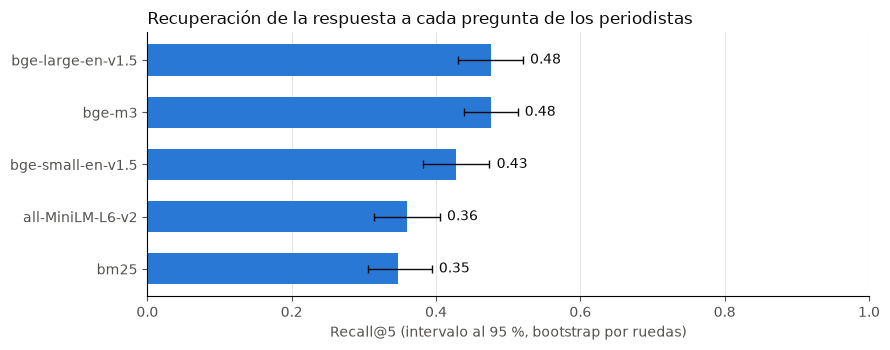

In [7]:
# Paleta del proyecto (la misma que en la fase 3)
AZUL, TINTA, TINTA_SECUNDARIA, REJILLA = "#2a78d6", "#0b0b0b", "#52514e", "#e6e5e0"

orden = tabla.iloc[::-1].reset_index(drop=True)   # el mejor, arriba
nombres = orden["modelo"].str.split("/").str[-1]
errores = [orden["recall@5"] - orden["r5_ic95_inf"], orden["r5_ic95_sup"] - orden["recall@5"]]

fig, ax = plt.subplots(figsize=(9, 3.6))
ax.barh(nombres, orden["recall@5"], color=AZUL, height=0.6)
ax.errorbar(orden["recall@5"], nombres, xerr=errores, fmt="none", ecolor=TINTA, capsize=3, linewidth=1)
for y, fila in orden.iterrows():
    ax.text(fila["r5_ic95_sup"] + 0.01, y, f"{fila['recall@5']:.2f}", va="center", color=TINTA)
ax.set_xlim(0, 1)
ax.set_xlabel("Recall@5 (intervalo al 95 %, bootstrap por ruedas)", color=TINTA_SECUNDARIA)
ax.set_title("Recuperación de la respuesta a cada pregunta de los periodistas", loc="left", color=TINTA)
ax.grid(axis="x", color=REJILLA, linewidth=0.8)
ax.set_axisbelow(True)
ax.spines[["top", "right"]].set_visible(False)
ax.tick_params(colors=TINTA_SECUNDARIA)
fig.tight_layout()
fig.savefig(resultados_dir / "recall_at_5.png", dpi=150)
plt.show()

## 6. Preguntas en español y coste

- `coincidencia_en_es`: proporción de los 5 fragmentos recuperados que coincide entre la versión inglesa y la española de la misma pregunta (1 = recupera lo mismo en ambos idiomas).
- `latencia_ms`: mediana del tiempo de una búsqueda con una sola pregunta, como en el chat. `indexado_s`: tiempo de calcular los embeddings de todos los fragmentos, que se hace una sola vez. `memoria_gb`: pesos del modelo.

In [8]:
costes.to_csv(resultados_dir / "costes.csv", index=False)
costes.round(3)

,modelo,carga_s,indexado_s,latencia_ms,memoria_gb,coincidencia_en_es
0,bm25,0.000,0.065,28.498,0.000,0.000
1,sentence-transformers/all-MiniLM-L6-v2,10.739,6.423,6.442,0.091,0.200
2,BAAI/bge-small-en-v1.5,2.954,12.236,10.505,0.133,0.300
3,BAAI/bge-large-en-v1.5,3.398,129.326,58.966,1.341,0.475
4,BAAI/bge-m3,29.926,145.675,66.123,2.271,0.750


## 7. Índice del chat

El índice del ganador se guarda en `data/history/rag_index/`: fragmentos, embeddings en float16 (con BM25 no hay embeddings; se reconstruye al cargar) y metadatos con el modelo usado. La app lo carga al arrancar y no recalcula nada.

In [9]:
guardar_indice(fragmentos, ganador, matrices[ganador])
print(f"Índice guardado en {HISTORY_DIR / 'rag_index'}: {len(fragmentos)} fragmentos, modelo {ganador}")

Índice guardado en /Users/eduardogonzalezarroyo/Developer/hawk-and-dove_BCE/data/history/rag_index: 3216 fragmentos, modelo BAAI/bge-large-en-v1.5


## 8. Prueba del chat

Tres preguntas representativas: una sobre la rueda más reciente, una en español y una sobre un hito del histórico. El tiempo de respuesta incluye búsqueda y generación; la carga de los modelos se hace antes, como hará la app al arrancar.

In [10]:
t0 = time.perf_counter()
preparar()
print(f"Carga del índice y del LLM: {time.perf_counter() - t0:.0f} s")

PREGUNTAS_PRUEBA = [
    "How has the ECB assessed the inflationary impact of the energy shock caused by the conflict in the Middle East?",
    "¿Qué dijo el BCE sobre los aranceles en 2025?",
    "Why did the ECB start cutting interest rates in June 2024?",
]


def mostrar(pregunta: str) -> float:
    """Imprime la respuesta y sus citas; devuelve el tiempo de respuesta en segundos."""
    t0 = time.perf_counter()
    resultado = responder(pregunta)
    segundos = time.perf_counter() - t0
    print(f"PREGUNTA: {pregunta}\n\n{resultado['answer']}\n")
    for i, cita in enumerate(resultado["citations"], start=1):
        print(f"[{i}] {cita['source']}\n    {cita['snippet'][:200]}...")
    print(f"\nTiempo de respuesta: {segundos:.1f} s\n" + "-" * 100)
    return segundos


tiempos = [mostrar(p) for p in PREGUNTAS_PRUEBA]

Fetching 9 files: 100%|██████████| 9/9 [00:00<00:00, 3115.35it/s]


Carga del índice y del LLM: 5 s
PREGUNTA: How has the ECB assessed the inflationary impact of the energy shock caused by the conflict in the Middle East?

The ECB has assessed that the energy shock from the conflict in the Middle East has led to a sharp increase in energy prices, pushing up inflation and weighing on economic sentiment [1]. The central bank emphasized that the implications for medium-term inflation depend on the intensity and duration of the energy price shock and the scale of its indirect and second-round effects [1]. The ECB also noted that a prolonged war could lead to a larger and longer-lasting upward shift in energy prices than currently expected, raising euro area inflation further [2]. Additionally, the ECB stated that the war has created upside risks for inflation and downside risks for economic growth [3].

[1] ECB press conference, 30 April 2026. Monetary policy statement
    The war in the Middle East has led to a sharp increase in energy prices, pushing up 

## 9. Decisión

**Recuperación: bge-m3. La decisión se aparta de la regla de la sección 4, que elegía bge-large-en-v1.5.**

- **Resultados.** bge-large-en-v1.5 y bge-m3 empatan en recall@5 (0,476 los dos; diferencia 0,000, IC 95 % [−0,042; +0,041]) y superan con claridad al resto en la comparación pareada: bge-small queda 4,8 puntos por debajo (IC [−8,5; −1,1]), MiniLM 11,6 y BM25 12,9, último pese a que la tarea le favorece. Los intervalos marginales del gráfico se solapan, pero la comparación relevante es la pareada, que descuenta la dificultad común de cada pregunta. El nivel absoluto, casi la mitad de las preguntas con la respuesta exacta entre los cinco primeros fragmentos, es una cota inferior: la respuesta a una pregunta parecida en otra rueda no cuenta como acierto.
- **Por qué no se aplica la regla.** La excepción multilingüe exigía que el límite inferior del intervalo de la diferencia superase −0,03. Con 542 consultas agrupadas en 55 ruedas, ese intervalo tiene una semiamplitud de unos 4 puntos aunque los dos modelos acierten lo mismo: la excepción solo podía activarse si bge-m3 superaba al mejor, no si lo igualaba, que era justo el caso que pretendía cubrir. El margen se fijó sin comprobar la precisión alcanzable con la muestra; es un error de diseño de la regla, no un resultado desfavorable para bge-m3.
- **Evidencia a favor de bge-m3.** Iguala a bge-large en recall@5, queda algo por delante en recall@1 (0,260 frente a 0,232) y en MRR@10 (0,352 frente a 0,332) y algo por detrás en recall@10 (0,566 frente a 0,574). En español recupera los mismos fragmentos que en inglés en el 75 % de los casos, frente al 48 % de bge-large. La prueba del chat lo confirma: con bge-large, la pregunta en español sobre los aranceles de 2025 recupera fragmentos que no tratan el tema y el chat responde que no hay información, aunque los aranceles aparecen en las ocho ruedas de 2025.
- **Coste.** 2,3 GB de memoria frente a 1,3 GB y 66 ms por búsqueda frente a 59 ms: irrelevante frente a los ~10 s de la generación y a los ~5 GB del LLM.
- **Chat.** Responde en unos 10 s en un Mac M4 con 24 GB, en local y sin coste por pregunta. Las dos respuestas de prueba en inglés son correctas, se limitan a lo que dicen los fragmentos y citan la rueda y el pasaje de los que sale cada afirmación.
- **Ajuste de las instrucciones.** Cuando los fragmentos no respondían a la pregunta, el LLM lo decía, pero citaba igualmente los cinco. Ahora se le pide que en ese caso no cite ninguno.
- **Índice definitivo.** La sección 10 reconstruye el índice con bge-m3 y repite la prueba del chat.

## 10. Índice definitivo y prueba del chat

Índice con bge-m3 y repetición de las tres preguntas de prueba. La celda es autónoma: solo necesita la primera celda del notebook (importaciones).

In [2]:
# Índice definitivo con bge-m3 (ver la decisión) y repetición de la prueba del chat
from src.text.models.retrieval_backends import crear_recuperador

DEFINITIVO = "BAAI/bge-m3"
fragmentos = construir_fragmentos(pd.read_parquet(HISTORY_DIR / "transcripts.parquet"))
recuperador = crear_recuperador(DEFINITIVO)
recuperador.indexar(fragmentos["indexed_text"].tolist())
guardar_indice(fragmentos, DEFINITIVO, recuperador.matriz)
del recuperador
print(f"Índice guardado en {HISTORY_DIR / 'rag_index'}: {len(fragmentos)} fragmentos, modelo {DEFINITIVO}\n")

preparar()
for pregunta in ["How has the ECB assessed the inflationary impact of the energy shock caused by the conflict in the Middle East?",
                 "¿Qué dijo el BCE sobre los aranceles en 2025?",
                 "Why did the ECB start cutting interest rates in June 2024?"]:
    t0 = time.perf_counter()
    resultado = responder(pregunta)
    print(f"PREGUNTA: {pregunta}\n\n{resultado['answer']}\n")
    for i, cita in enumerate(resultado["citations"], start=1):
        print(f"[{i}] {cita['source']}\n    {cita['snippet'][:200]}...")
    print(f"\nTiempo de respuesta: {time.perf_counter() - t0:.1f} s\n" + "-" * 100)

/Users/eduardogonzalezarroyo/Developer/hawk-and-dove_BCE/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 391/391 [00:00<00:00, 57090.19it/s]


Índice guardado en /Users/eduardogonzalezarroyo/Developer/hawk-and-dove_BCE/data/history/rag_index: 3216 fragmentos, modelo BAAI/bge-m3



Fetching 9 files: 100%|██████████| 9/9 [00:00<00:00, 3356.64it/s]


PREGUNTA: How has the ECB assessed the inflationary impact of the energy shock caused by the conflict in the Middle East?

The ECB has assessed that the energy shock from the Middle East conflict has led to a sharp increase in energy prices, pushing up inflation and affecting economic sentiment [1]. It noted that the implications for medium-term inflation depend on the intensity and duration of the energy price shock and its indirect and second-round effects [1]. The ECB also mentioned that a prolonged disruption in the supply of oil and gas would result in inflation being above baseline projections [2]. Furthermore, the risks to the inflation outlook are tilted to the upside, especially if the war leads to a larger and longer-lasting upward shift in energy prices [3]. The ECB emphasized that the longer energy prices stay high, the more likely they are to drive up broader inflation through indirect and second-round effects [4].

[1] ECB press conference, 30 April 2026. Monetary policy 

**Resultado.** Con bge-m3, la pregunta en español recupera la declaración del 11 de septiembre de 2025 sobre el freno de los aranceles al crecimiento, y el chat responde en español con su cita. Las dos preguntas en inglés mantienen respuestas correctas y citadas; la del shock energético se apoya ahora en cuatro pasajes de marzo, abril y septiembre de 2026. Tiempo de respuesta: entre 9 y 12 s.

**Límite.** Una pregunta amplia, como la de los aranceles en todo 2025, recibe una respuesta parcial: el chat solo ve los cinco fragmentos más parecidos a la pregunta y no recorre todas las ruedas del año.